# Projet : Les accidents corporels routiers en France 

## Introduction

Nous voulons étudier les accidents corporels de la route en France. Pour ce faire nous avons récoltés les données issus de la base de données annuelles des accidents corporels de la circulation routière (BAAC). Cette base comporte quatre fichier principaux, avec un fichier par année. Pour avoir plusieurs années à notre disposition, nous avons retenu les fichiers des années 2022, 2023 et 2024, soit 12 fichiers pour l'import de données.

Ces quatres fichiers nous informent sur :
- les caractéristiques de l'accidents ;
- le lieux de l'accidents ;
- les véhicules impliqués dans l'accidents ;
- les usagers impliqués dans l'accidents.

Chacun de ces fichiers comporte plusieurs variables qui caractérisent l'accidents et les informations auxiliaires. Nous étudierons avec un intérêt particulier la variable de gravité des blessures des usagers impliqués dans les accidents.

Notre problématique s'articule autour des questions suivantes : *Quels facteurs influencent la gravité des accidents corporels de la route en France ? Peut-on prédire cette gravité en tenant compte des caractéristiques (environnementales, géographiques, routières, etc.) de l'accident ?*

Nous commencerons par présenter les données et le traitement de celles-ci. Puis nous répondrons au sujet avec des analyses descriptives et de la modélisation, avant de conclure sur nos résultats. 

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Traitement
from src.donnees import import_donnees, renomer_cle_jointure, concatenation_annees
from src.nettoyage import recodage, mapping_renommer_colonnes, colonnes_a_supprimer, création_age_usager, jointure, creation_mois_num, rajout_colonnes

# Analyse descriptive
from src.fct_carto import creation_df_carte, carte_departement
from src.fonction_analyse import effectif_frequence, tableau_propre_effectif_frequence, chi2_cramer, tableau_propre_cramer, evolution_mensuelle, nb_accidents_par, tab_cont_grav, bar_chart

# Modelisation
from src.fct_modelisation import y_x_train_test, importance_variable, importance_variable_gravite
from src.fct_sortie_propre import beau_report, matrice_confusion, beau_importances, beau_importance_gravite, belle_colonnes, belle_head

## I - Traitement des données

Nous avons réalisé des analyses préliminaires sur nos données (disponibles dans le fichier pre-processing.ipynb). Cela nous a permis de relever certains problèmes que nous avons pris en compte pour le nettoyage de nos données ci-dessous (valeurs manquantes, noms de colonnes, doublons...).

In [6]:
donnees_completes = import_donnees()

donnees_completes["caract"][22] = renomer_cle_jointure(donnees_completes["caract"][22], "Num_Acc", "Accident_Id")

/home/onyxia/work/Projet_pythonDS/src/donnees.py:8: DtypeWarning: Columns (0: lartpc) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(nom_fichier_csv, sep=';', encoding='UTF-8')
/home/onyxia/work/Projet_pythonDS/src/donnees.py:8: DtypeWarning: Columns (0: nbv) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(nom_fichier_csv, sep=';', encoding='UTF-8')


In [7]:
# CARACTERISTIQUE
df_caract = concatenation_annees(donnees_completes, "caract")
df_caract = creation_mois_num(df_caract)
# LIEUX
df_lieux = concatenation_annees(donnees_completes, "lieux")
# VEHICULE
df_vehicule = concatenation_annees(donnees_completes, "vehicule")
# USAGER
df_usager = concatenation_annees(donnees_completes, "usager")

In [8]:
mappings = mapping_renommer_colonnes()

In [9]:
# recodage des noms des colonnes 
df_caract_recoder = recodage(df_caract, mappings["caract"])
df_lieux_recoder = recodage(df_lieux, mappings["lieux"])
df_vehicule_recoder = recodage(df_vehicule, mappings["vehicule"])
df_usager_recoder = recodage(df_usager, mappings["usager"])

# supprimer les doublons de corrections des données dans le fichier lieux 
df_lieux_recoder = df_lieux_recoder.drop_duplicates(subset="Num_Acc", keep="last")

# age pour les usagers
df_usager_recoder = création_age_usager(df_usager_recoder)

In [10]:
df_final = jointure(df_caract_recoder, df_lieux_recoder, df_vehicule_recoder, df_usager_recoder)

In [11]:
colonnes_a_supprimer = colonnes_a_supprimer()
df_final = df_final.drop(columns=colonnes_a_supprimer, errors="ignore")
df_final = df_final.dropna(subset=["id_usager"])

In [12]:
df_final = rajout_colonnes(df_final)

In [ ]:
belle_colonnes(df_final)

Num_Acc,jour,mois,an,hrmn,lum,dep,agg,int,atm,col,lat,long,mois_num,catr,circ,prof,plan,surf
infra,situ,vma,id_vehicule,catv,obs,obsm,choc,manv,id_usager,catu,grav,sexe,trajet,secu1,age,date,jour_semaine,hr


In [ ]:
belle_head(df_final)

,Num_Acc,jour,mois,an,hrmn,lum,dep,agg,int,atm,col,lat,long,mois_num,catr,circ,prof,plan,surf,infra,situ,vma,id_vehicule,catv,obs,obsm,choc,manv,id_usager,catu,grav,sexe,trajet,secu1,age,date,jour_semaine,hr
0,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,Hors agglomération,Hors intersection,Brouillard - fumée,Deux véhicules - frontale,"47,56277000","6,75832000",3,Route départementale,Bidirectionnelle,Plat,En courbe à gauche,Normale,Aucun,Sur chaussée,90,155 781 758,VL,Sans objet,Véhicule,Avant,Déporté,203 988 581,Conducteur,Blessé hospitalisé,Homme,Domicile - École,Ceinture,23,2024-03-25 00:00:00,Lundi,07
1,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,Hors agglomération,Hors intersection,Brouillard - fumée,Deux véhicules - frontale,"47,56277000","6,75832000",3,Route départementale,Bidirectionnelle,Plat,En courbe à gauche,Normale,Aucun,Sur chaussée,90,155 781 759,PL,Sans objet,Véhicule,Avant droit,Manœuvre d’évitement,203 988 582,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,29,2024-03-25 00:00:00,Lundi,07
2,202400000002,20,mars,2024,15:05,Plein jour,21,En agglomération,Intersection en T,Temps éblouissant,Autre collision,"47,02109000","4,83755000",3,Voie communale,À sens unique,Plat,Partie rectiligne,Autre,Aucun,Sur chaussée,30,155 781 757,VU,Sans objet,Piéton,Avant gauche,Tournant,203 988 579,Piéton,Blessé hospitalisé,Femme,Promenade - loisirs,Aucun équipement,99,2024-03-20 00:00:00,Mercredi,15
3,202400000002,20,mars,2024,15:05,Plein jour,21,En agglomération,Intersection en T,Temps éblouissant,Autre collision,"47,02109000","4,83755000",3,Voie communale,À sens unique,Plat,Partie rectiligne,Autre,Aucun,Sur chaussée,30,155 781 757,VU,Sans objet,Piéton,Avant gauche,Tournant,203 988 580,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,39,2024-03-20 00:00:00,Mercredi,15
4,202400000003,22,mars,2024,19:30,Crépuscule ou aube,15,Hors agglomération,Hors intersection,Normale,Autre collision,"44,90238400","2,49641800",3,Voie communale,Bidirectionnelle,Plat,Partie rectiligne,Normale,Aucun,Sur accotement,50,155 781 756,Voiturette,Mobilier urbain,Piéton,Avant,Sans changement de direction,203 988 574,Passager,Blessé léger,Femme,Promenade - loisirs,Non déterminable,19,2024-03-22 00:00:00,Vendredi,19


Certaines variables prennent la valeur « Non renseigné ». Nous avons les avons traitées de deux manières, en considérant plusieurs éléments :
- Nous avons supprimé les lignes si les NA y étaient représentés en faible quantité et si la colonne était importante (pertinente pour l'analyse de la gravité). Par exemple, les NA représentent 359 observations sur plus de 350 000 pour la colonne de la gravité, il s'agit d'une faible proportion pour une variable indispensable pour nos analyses.
- Nous avons supprimé les colonnes s'il y avait beaucoup de NA et si la colonne n'était pas forcément pertinente.

La répartition des indemnes, blessés et tués parmi les valeurs non renseignées était généralement très proche de celles des autres valeurs du jeu de données, à l'exception de certaines variables qui ne comprenaient que des indemnes. Ce sont ce type de NA que nous avons supprimé. Nous avons en revanche conservé la variable trajet (29 % de NA), car la proportion de « Tués » était trop importante pour pouvoir supprimer les NA de cette variable. Il en est de même pour le régime de circulation. Nous les avons donc conservées pour d'éventuelles analyses, bien que la modélisation ne les prenne pas en compte.

In [15]:
# suppression des NA 
df_final = df_final.dropna(subset=["lum", "int", "atm", "col", "prof", "plan", "surf", "situ", "catv", "obs", "obsm", "choc", "sexe", "age", "secu1"])

## II - Analyse descriptive des accidents corporels en France

### 1. Vue d'ensemble

La base de données dénombre 163942 accidents sur la période 2022-2024. Ces accidents ont impliqué 367699 usagers, à divers degrés de gravité.

La gravité des blessures associée à chaque usager se présente sous la forme de quatre modalités.
- Indemne ;
- Blessé léger ;
- Blessé hospitalisé ;
- Tué.

Leur répartition est la suivante :

In [16]:
eff_freq = effectif_frequence(df_final, "grav")
tableau_propre_effectif_frequence(eff_freq)

GT(_tbl_data=                 grav  effectif  frequence
0             Indemne    151609     0.4123
1        Blessé léger    148525     0.4039
2  Blessé hospitalisé     57275     0.1558
3                 Tué     10290     0.0280
4               Total    367699     1.0000, _body=<great_tables._gt_data.Body object at 0x7f401724c590>, _boxhead=Boxhead([ColInfo(var='grav', type=<ColInfoTypeEnum.default: 1>, column_label='Gravité', column_align='left', column_width=None), ColInfo(var='effectif', type=<ColInfoTypeEnum.default: 1>, column_label='Effectif', column_align='right', column_width=None), ColInfo(var='frequence', type=<ColInfoTypeEnum.default: 1>, column_label='Fréquence', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f401724c050>, _spanners=Spanners([]), _heading=Heading(title='Gravité des accidents pour les usagers', subtitle='Répartition des effectifs et des fréquences pour la variable « gravité »', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f401724c980>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f401725c410>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f401724cad0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f401724cec0>, <great_tables._gt_data.FormatInfo object at 0x7f401725c690>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss

Différents facteurs peuvent être corrélés à la gravité de l'accident pour l'usager. Les tests du chi-deux entre la gravité et toutes les variables qualitatives retenues ont rejeté l'hypothèse d'indépendance à tous les seuils. Nous pouvons dès lors nous intéresser au V de Cramèr de ces variables pour mettre en évidence celles où l'association est la plus forte.

In [17]:
chi2_cramer = chi2_cramer(df_final, "grav")[["variable", "v_cramer"]]
tableau_propre_cramer(chi2_cramer)

GT(_tbl_data=                                           variable  v_cramer
0                            Équipement de sécurité    0.2671
1                             Catégorie du véhicule    0.2443
2                             Catégorie de l'usager    0.1669
3                          En ou hors agglomération    0.1663
4             Manoeuvre principale avant l'accident    0.1605
5                         Département de l'accident    0.1548
6                              Obstacle fixe heurté    0.1547
7                                 Type de collision    0.1511
8                            Obstacle mobile heurté    0.1443
9                           Situation de l'accident    0.1284
10                            Point de choc initial    0.1274
11                                   Type de trajet    0.1244
12                               Catégorie de route    0.1033
13                                 Sexe de l'usager    0.0914
14                            Régime de circulation    0.0862
15                                    Tracé en plan    0.0712
16             Luminosité et conditions d'éclairage    0.0684
17                                     Intersection    0.0564
18                                            Heure    0.0546
19  Déclivité de la route à l'endroit de l'accident    0.0416
20                        Conditions atmosphériques    0.0329
21                               Jour de la semaine    0.0315
22                    Infrastructure ou aménagement    0.0270
23                               État de la surface    0.0263
24                               Mois de l'accident    0.0218, _body=<great_tables._gt_data.Body object at 0x7f40cd40c9d0>, _boxhead=Boxhead([ColInfo(var='variable', type=<ColInfoTypeEnum.default: 1>, column_label='Variable', column_align='left', column_width=None), ColInfo(var='v_cramer', type=<ColInfoTypeEnum.default: 1>, column_label='V de Cramèr', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f401725ce10>, _spanners=Spanners([]), _heading=Heading(title='Association entre la gravité et différentes variables', subtitle='\n                Résultats des V de Cramèr\n                entre la gravité et différentes variables qualitatives\n            ', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f401725cb90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f40cd40e520>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f401725d1d0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f401725d810>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsI

On remarque ainsi que l'équipement de sécurité, les catégories du véhicule et de l'usager sont les plus corrélés à la gravité de l'accident. Ces facteurs sont suivis par des caractéristiques relevant des circonstances de l'accident (manoeuvre, obstacle heurté, situation, point de choc initial), et la caractéristique géographique du département. Nous accorderons une attention particulière à certaines de ces variables, que nous nous proposons d'étudier plus en détail dans l'une des sous-parties suivantes.

### 2. Évolution des accidents dans le temps

#### Évolution sur la période

Sur la période 2022-2024, le nombre d'accidents est comparable entre les trois années. L'évolution d'un mois à l'autre se présente comme suit :

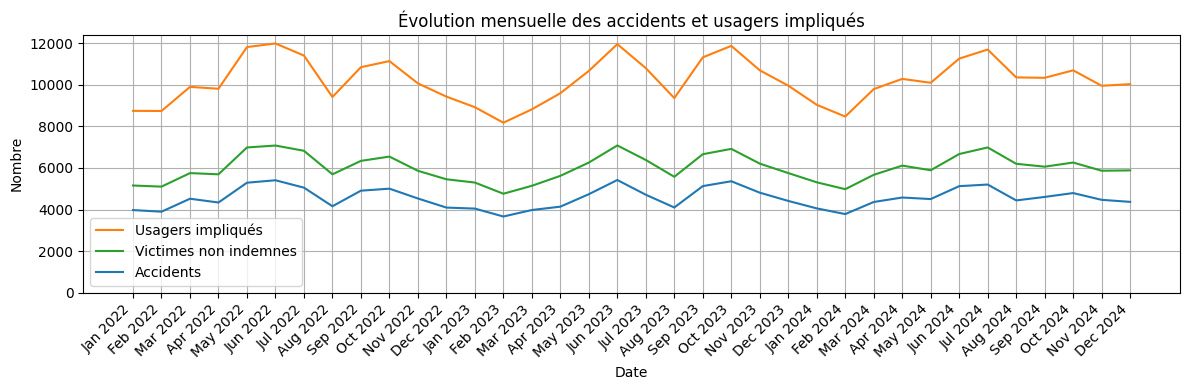

In [18]:
evolution_mensuelle(df_final)

On constate d'une part que si à l'année le nombre d'accidents ne semble pas présenter de tendance, il varie d'un mois à l'autre en restant compris entre 3600 et 5300. D'autre part, le nombre d'accidents est généralement reflété par le nombre d'usagers impliqués (deux à trois usagers pour un accident en moyenne), lui-même reflété par le nombre de victimes (les usagers blessés ou tués). Les usagers indemnes représentent 41,2 % de ceux impliqués dans les accidents corporels de la base de données.

#### Évolution hebdomadaire et horaire

Le vendredi est le jour de la semaine qui cumule le plus d'accidents (26804), et le dimanche le moins (20102). Le reste de la semaine comporte des valeurs aux alentours de 22000 ou 23000.

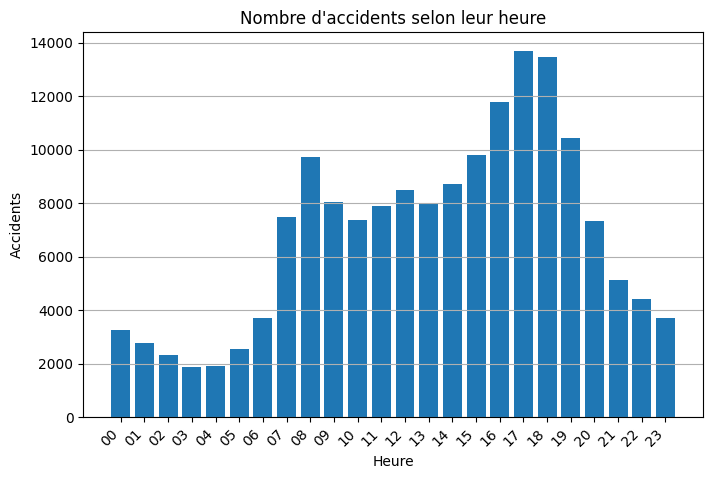

In [19]:
nb_accidents_par(df_final, "hr", "Heure")


On observe deux modes aux heures de pointes, à 8 et 17 heures (et cela est exacerbé les jours de semaine). Les accidents sont ensuite plus nombreux de jour que de nuit, et laissent supposer que leur nombre reflète au moins en partie l'intensité du trafic. 

### 3. Nombre et gravité des accidents selon les facteurs extérieurs

#### Conditions atmosphériques et météorologiques

La majeure partie des accidents a lieu dans des conditions de conduite « normales » : sans défaut de visibilité dû à la météo ni problème d'éclairage, et sur des routes non altérées par l'environnement. La rareté des phénomènes inhabituels se retranscrit par une faible occurrence dans les données. Mises à part les conditions d'éclairage, les conditions qui dépendent directement ou indirectement de l'environnement sont de l'ordre des centaines seulement lorsqu'elles sortent de l'ordinaire.

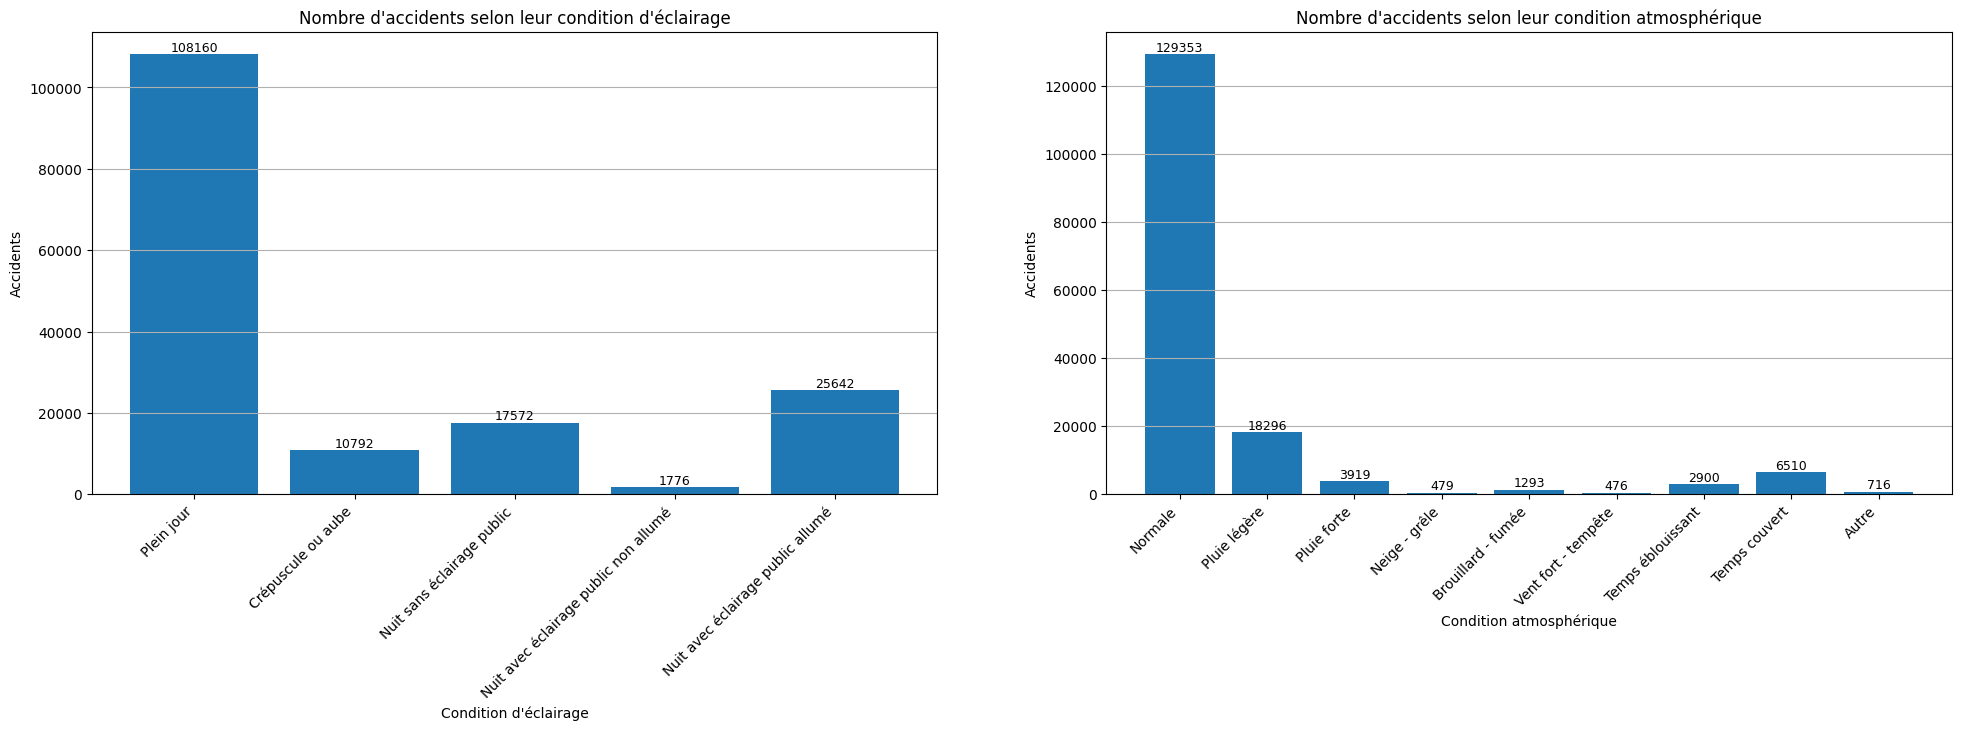

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(24, 6))

nb_accidents_par(df_final, "lum", "Condition d'éclairage", True, True, ax=axes[0])
nb_accidents_par(df_final, "atm", "Condition atmosphérique", True, True, ax=axes[1])

In [21]:
nb_accidents_par(df_final, "atm", "Condition atmosphérique", True, True, ax=axes[1])

Il est en outre possible de s'intéresser à la gravité des accidents pour ces différentes modalités :

In [23]:
tc_atm_grav = tab_cont_grav(df_final, "atm")
bar_chart(tc_atm_grav, "Conditions atmosphériques", "Répartition de la gravité de l'accident selon les conditions atmosphériques")

KeyboardInterrupt: 

Les situations où la visibilité est affectée semblent être les plus fatales. 6,3 % des usagers impliqués dans un accident de nuit sans éclairage public ont trouvé la mort (4,7 % pour les accidents avec éclairage public non allumé). Ce chiffre n'est que de 1,6 % avec ledit éclairage allumé, et de 2,3 % en plein jour.

De surcroît, le brouillard et/ou la fumée constituent la modalité associée à la plus forte mortalité parmi les conditions atmosphériques directes avec 6,4 % de tués.

In [ ]:
tc_surf_grav = tab_cont_grav(df_final, "surf")
bar_chart(tc_surf_grav, "Surface au sol", "Répartition de la gravité de l'accident selon la surface")

Bien que ces deux surfaces concernent un faible nombre d'accidents dans les données, la proportion de tués est plus grande lorsque les accidents ont lieu sur des surfaces inondées (87 accidents) ou boueuses (143) par rapport aux autres situations : 9,6 % et 7,6 % respectivement.

La part de blessés hospitalisés est particulièrement importante dans ce second cas (36,4 %, soit 10 points de plus que les autres types de surface spécifiés).

#### Conditions routières

On traitera ici des conditions de conduite associées à la route elle-même ou au type de circulation.

In [ ]:
tc_catr_grav = tab_cont_grav(df_final, "catr")
bar_chart(tc_catr_grav, "Catégorie de route", "Répartition de la gravité de l'accident selon la catégorie de route")

Les accidents ont surtout lieu sur le réseau public, avec notamment 68487 accidents sur voie communale et 62463 sur route départementale. Si les routes hors réseau ont une proportion de tués légèrement plus importante, ce sont aussi celles avec le moins d'observations : 177.

Les voies bidirectionnelles sont les plus représentées parmi les observations. Malheureusement, les valeurs manquantes sont assez nombreuses pour cette variable, mais leur répartition de la gravité associée ne diffère pas drastiquement de celle des autres modalités.

#### Caractéristiques de l'accident

Nous nous intéressons ici à quelques facteurs venant caractériser l'accident : type de collision, endroit du choc, objet percuté...

In [ ]:
nb_accidents_par(df_final, "col", "Type de collision", True, True)

tc_col_grav = tab_cont_grav(df_final, "col")
bar_chart(tc_col_grav, "Type de collision", "Répartition de la gravité de l'accident selon le type de collision")

L'absence de collision est le cas le plus fatal (6,4 %) parmi les situations où le type (ou l'absence) de collision est spécifié, et c'est aussi le cas avec le moins d'indemnes : 16,8 % seulement. Elle est suivie par la catégorie « Autre », puis par la collision frontale entre deux véhicules, et le cas de collisions multiples entre trois véhicules. On remarque que pour les collisions entre trois véhicules, plus de la moitié des usagers impliqués dans l'accident s'en sortent indemnes.

In [ ]:
tc_choc_grav = tab_cont_grav(df_final, "choc")
bar_chart(tc_choc_grav, "Choc initial", "Répartition de la gravité de l'accident selon l'endroit du choc initial")

Les chocs à l'avant concernent la grande majorité des accidents (62543 accidents dans la base de données). Les chocs multiples (tonneaux) sont les moins représentés (3147) mais aussi ceux qui comportent le plus de blessés et tués (83,5 % des usagers impliqués) et sont mortels pour 6,8 % des usagers. Les cas avec les conséquences les plus graves sont ensuite ceux où il n'y a techniquement pas de choc (5 % de tués), les chocs complètement à l'avant, les chocs latéraux, les avants gauche et droit, et enfin les chocs arrières.

Enfin, la proportion de blessés et tués est également affectée par la catégorie du ou des véhicules impliqués dans l'accident. Plus ce dernier est robuste, plus la proportion d'indemnes est grande. Ce sont globalement les accidents impliquant des deux-roues qui ont le plus de chance de comporter des blessés.

#### Caractéristiques de l'usager

Les positions et équipements des individus impliqués dans un accident de la route peuvent affecter leurs chances de survie et leurs risques de blessure.

In [ ]:
tc_catu_grav = tab_cont_grav(df_final, "catu")
bar_chart(tc_catu_grav, "Catégorie d'usager", "Répartition de la gravité de l'accident selon la catégorie de l'usager")

La gravité de l'accident est drastiquement différente entre les usagers véhiculés et les usagers piétons. Ces derniers sont beaucoup plus vulnérables et ne s'en sortent indemnes que dans 3,2 % des cas, contre 37,7 % et 46,1 % des cas pour les deux autres catégories. Les usagers piétons s'en sortent majoritairement blessés.

In [ ]:
nb_accidents_par(df_final, "secu1", "Équipement de sécurité", True, True)

tc_secu1_grav = tab_cont_grav(df_final, "secu1")
bar_chart(tc_secu1_grav, "Équipement de sécurité", "Répartition de la gravité de l'accident selon l'équipement de sécurité")

L'équipement de sécurité est un autre facteur qui affecte grandement les proportions de la gravité. Ici, toutes les barres du graphique ne sont pas interprétables : les airbags étaient peu représentés, et les proportions qui ont utilisé cette modalité manquent de généralité. 

Du reste, on peut remarquer que le risque de blessure ou de mort diminue de moitié entre l'absence de sécurité et l'équipement d'au moins une ceinture. Cela est cependant nuancé par le fait que l'absence de sécurité peut dans une partie de ces cas être associée à des véhicules deux roues ne comportant pas de ceintures. 

C'est également sous ce prisme que l'on observe la vulnérabilité associée à l'équipement du casque et des gants : ils concernent avant tout les accidents deux-roues, plus mortels que les accidents des véhicules plus imposants.

### 4. Dans quel département français les accidents sont-ils les plus graves ? Un peu de cartographie

Nous souhaitons voir si certains départements ont plus d'accidents graves que d'autres ou inversement. Il peut y avoir plusieurs victimes par accident. Nous considérons donc ici le nombre de victimes et non le nombre d'accidents.

Le nombre d'accidents par département est très inégal. On observe notamment beaucoup d'accident dans les départements en Ile-de-France : cela peut s'expiquer par le fait que la population y est plus importante.
Pour cette raison, et pour rester en accord avec notre problématique, nous étudions la proportion des blessures d'accident plutôt que le nombre total d'accident qui est en outre disproportionné en fonction des départements.

In [ ]:
df_victimes_blessure = creation_df_carte(df_final, blessure=True)
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

carte_departement(df_victimes_blessure, blessure="Tué", ax=axes[0])
carte_departement(df_victimes_blessure, blessure="indemne", ax=axes[1])

plt.tight_layout()
plt.show()

Les victimes tués par un accident sont une faible proportion des victimes. Par ailleurs, on les observe le plus dans la diagonale du vide. En revanche, les accidents indemne sont plus situés dans le nord de la France. En Ile-de-France, les accidents sont majoritairement moins mortels que les autres départements.

In [ ]:
df_victimes_an_blessure = creation_df_carte(df_final, an=True, blessure=True)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

carte_departement(df_victimes_an_blessure, blessure="tué", an=2022, ax=axes[0])
carte_departement(df_victimes_an_blessure, blessure="tué", an=2023, ax=axes[1])
carte_departement(df_victimes_an_blessure, blessure="tué", an=2024, ax=axes[2])

fig.suptitle("Comparaison des tués par département – 2022 / 2023 / 2024", fontsize=18)
plt.tight_layout()
plt.show()

La proportion de tué pour chaque année est répartie pour l'ensemble de la même manière. En 2023, on remarque une lègere augmentation des proportion de tués. Les départements les plus mortels sont majoritairement dans la diagonal du vide comme la Creuse (23), la Dordogne (24) et la Haute-Marne par exemple. 

# III - Classification de la gravité d'un accident par un Random Forest

Nous nous intéressons à la prédiction de la gravité des blessures des usagers impliqués d'un accident de la route. Pour ce faire nous allons étudier :
- la variable gravité (variable catégorielle à expliquer) : 1 = Indemne, 2 = Blessé léger, 3 = Blessé hospitalisé, 4 = Tué ;
- un Random Forest, nous permettant de classifier nos données ;
- des facteurs clés pour classifier la gravité des accidents : point de choc initial, âge de l'usager, sexe, équipements de sécurité, luminosité, état de la chaussée, type de route (autoroute, nationale, départementale), zone (agglomération/hors agglomération), département, heure, jour de la semaine, etc.

Les valeurs manquantes des variables que nous allons utiliser ci-après ont déjà été gérées (en l'occurrance supprimées) dans la première phase de ce projet. Les variables comportant encore des valeurs manquantes dans nos données ne seront pas utilisées pour les modèles ou supprimées en amont.

In [ ]:
# Graine de reproductibilité
np.random.seed(66)
random.seed(66)

In [ ]:
# Codage de la variable cible en numérique
grav_dict = {
    "Indemne":1,
    "Blessé léger":2,
    "Blessé hospitalisé":3,
    "Tué":4,
}
df_final_modele = recodage(df_final, {"grav": grav_dict})

### Encodage des variables explicatives 

Nous identifions les variables les plus pertinentes pour notre analyse. Pour la variable heure, nous effections un regroupement en fonction des modalités : nuit (00–06), matin (06–12), après‑midi (12–18), soir (18–24). 
Puis nous séparons les valeurs en jeux d'entrainement et de test, en prenant soin de coder les variables catégorielles (toutes sauf l'âge).

In [ ]:
# Séparation du jeu de donnée en y et X puis en jeu d'entrainement et de test en passant par l'encodage
# suppression NA de manv
df_final_modele = df_final_modele.dropna(subset=["manv"])
X_train, X_test, y_train, y_test = y_x_train_test(
    df_final_modele, 
    "grav", 
    [
        "mois",
        "an",
        "lum",
        "dep",
        "agg",
        "int",
        "surf",
        "catv",
        "obs",
        "obsm",
        "choc",
        "sexe",
        "situ",
        "secu1",
        "age",
        "atm",
        "col",
        "catr",
        "prof",
        "plan",
        "manv",
        "catu",
        "jour_semaine"
    ]
)

### Entrainement du modèle 

Nous avons besoin d'identifier correctement les classes rares, comme "Tué", car cela constitue une modalité critique pour les accidents que nous voulons expliquer. Nous avons donc attribuer des poids aux différentes classes. 

In [ ]:
poids = {
    "1": 1,   # indemne
    "2": 1.07,   # blessé léger
    "3": 2.77,   # blessé hospitalisé
    "4": 15.4   # tué
}

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight=poids,
    random_state=66,
    n_jobs=-1
)

rf.fit(X_train, y_train)


### Evaluation et importance des facteurs 

In [ ]:
y_pred = rf.predict(X_test)
beau_report(y_test, y_pred)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
matrice_confusion(cm)

Les classes 1 et 2 sont bien prédites, mais les classes 3 et 4 le sont beaucoup moins. Cela est du au fait que les données comportent moins d'accidents sur ces gravités de blessures(Blessés hospitalisés et tués). Surtout au niveau des "Tué", le modele ne retrouve de 22 % de bonne valeurs, ce qui est plutot faible. Même si le modèle a une accuracy globale correct de 66 %, le modèle malgrès l'utilisation des poids ne peut pas être considérer comme performant car nous voulons prédire les tués avec justesse, pour identifier les élements les plus graves.
La matrice de confusion confirme ces résultats. On peut notamment voir que le modèle a prédit plus de gravités "Tué" en "Blessés hospitalisés" que en "Tué"

Nous testons alors un second modèle le BalancedRandomForestClassifier qui est spécialement conçue pour les données déséquilibrées, cela permet de mieux prendre en compte les classes rares :

In [ ]:
brf = BalancedRandomForestClassifier(
    n_estimators=400,
    sampling_strategy="auto",
    random_state=66,
    n_jobs=-1
)

brf.fit(X_train, y_train)

In [ ]:
y_pred_brf = brf.predict(X_test)
beau_report(y_test, y_pred_brf)

In [ ]:
cm = confusion_matrix(y_test, y_pred_brf)
matrice_confusion(cm)

Ce modèle détecte nettement mieux les classes rares. En revanche, il y a aussi une baisse de la précision car le modèle a plus tendance a prédire un accident "Tué" à tort. Mais l'accuracy global du modèle reste toujours satisfaisante avec 60 %. Comme on peut le voir dans la matrice de confusion, le modèle prédit beaucoup plus les classes "Tué" à tort comparé à la matrice de confusion du modèle précédent.

### Tentative d'amélioration du modèle avec l'optimisation des paramètres (GridSearchCV)


In [ ]:
param_grid = {
    "n_estimators": [100],   
    "max_depth": [None, 12, 20], 
    "class_weight": [
        {"1":1, "2":1, "3":2, "4":6},
        {"1":1, "2":1, "3":3, "4":15},
        "balanced_subsample"
    ]
}

In [ ]:
rf_grid = RandomForestClassifier(
    random_state=66,
    n_jobs=1
)

grid = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    scoring="recall_macro",
    refit="recall_macro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)


In [ ]:
print("Meilleurs paramètres :", grid.best_params_)
print("Meilleurs score :", grid.best_score_)

La gridsearch considèrent optimaux les paramètres ci-dessus. Nous retenons donc ceux-ci pour effectuer un nouveau modèle :

In [ ]:
rf_opti = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=66,
    n_jobs=-1
)

rf_opti.fit(X_train, y_train)

y_pred = rf_opti.predict(X_test)
beau_report(y_test, y_pred)


En optimisant les paramètres et en utilisant le scoring "recall_macro", notre modèle détecte bien les usagers Tués, mais la performance dans l'ensemble décroît. 
Pour analyser l'importance des variables, nous allons choisir le modèle réalisé avec balancedRandomForest, qui est meilleur pour la détéction des classes rares que le modèle réalisé avec gridsearch. En revanche, ce modèle est moins bon globalement que le premier modèle RandomForest que nous avons effectué. Cependant comme nous voulons identifier les gravités (sans manquer les classes les plus rares), nous garderons celui-ci.

In [ ]:
beau_importances(importance_variable(brf, X_train))

In [ ]:
# Corrélation entre variables et probabilité de la gravité "Tué"
beau_importance_gravite(importance_variable_gravite(brf, X_test, 3))

In [ ]:
# Corrélation entre variables et probabilité de la gravité "Indemne"
beau_importance_gravite(importance_variable_gravite(brf, X_test, 0))

On observe donc plusieurs variables qui sont corrélées au fait d'avoir des blessures plus graves que d'autres.
- L'équipement de sécurité : les "Tués" ont une corrélation de -0,32 avec le port de la ceinture de sécurité et 0,29 pour le port d'aucun équipement; le fait de ne pas avoir d'équipement de sécurité est fortement associé au fait d'avoir des accidents graves (et inversement pour les "Indemnes").
- Le type de route : hors agglomération et route départementale accentuent la vulnérabilité des usagers.
- La catégorie de véhicule : les véhicule lourds (VL) sont plus associés à des blessures lègéres.


## Conclusion

Les conséquences corporelles des accidents pour les usagers sont avant tout affectées par leur situation au moment du fait. L'absence d'équipement de sécurité, le fait d'être piéton ou le fait d'être impliqué avec un véhicule léger accroît leur vulnérabilité. Des gestes simples, comme l'utilisation de la ceinture de sécurité, ne peuvent donc qu'être encouragés.

Géographiquement, c'est dans les départements plus ruraux et en dehors des agglomérations que les accidents sont les plus mortels, comme l'ont montré nos analyses descriptives et notre modélisation. Des facteurs environnementaux peuvent également, dans une moindre mesure, affecter l'issue des accidents.